# Evaluation + Research Figures — PyTorch
### MedAI Diagnose | CNN + NLP + PEPA

**Run order:** Step 4 — after train.ipynb

**Figures generated:**
- Fig 3: Internal variant comparison (Top-1 vs Top-3)
- Fig 4: Ablation study 3-metric grouped bars
- Fig 5: Component-wise delta gain over RF baseline
- Fig 6: Multi-metric radar chart

In [8]:
# Cell 1 — Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

RESULTS = '../results'
FIGS    = f'{RESULTS}/figures'
os.makedirs(FIGS, exist_ok=True)

# Colour palette
WHITE  = '#FFFFFF'
BLUE   = '#185FA5'
LBLUE  = '#B5D4F4'
AMBER  = '#EF9F27'
AMBER2 = '#FAC775'
TEAL   = '#0F6E56'
GREEN  = '#9FE1CB'
GRAY   = '#5F5E5A'
LGRAY  = '#D3D1C7'
RED    = '#A32D2D'

plt.rcParams.update({
    'font.family'        : 'DejaVu Sans',
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'figure.dpi'         : 150,
})
print('✓ Plotting setup ready')

✓ Plotting setup ready


In [9]:
# Cell 2 — Load Results
path = f'{RESULTS}/ablation_results.csv'

if not os.path.exists(path):
    raise FileNotFoundError(f'Run train.ipynb first. Expected: {path}')

df = pd.read_csv(path)
print('Ablation results loaded:')
print(df.to_string(index=False))

labels    = df['variant'].tolist()
top1_vals = df['top1'].tolist()
top3_vals = df['top3'].tolist()
f1_vals   = df['f1'].tolist()
x         = np.arange(len(labels))

Ablation results loaded:
variant                     name  top1  top3     f1    time
     A1 Random Forest (baseline) 80.31 92.98 0.8116    17.1
     A2                 CNN only 67.80 86.30 0.6544  3960.2
     A3                 NLP only 85.27 96.50 0.8546  2909.9
     A4           CNN+NLP concat 86.70 96.81 0.8677  4717.2
     A5             CNN+NLP mean 86.75 96.98 0.8691  6937.4
     A6          PEPA no dropout 86.95 97.14 0.8696  5208.6
     A7  CNN+NLP+PEPA (proposed) 87.00 97.14 0.8707 23585.2


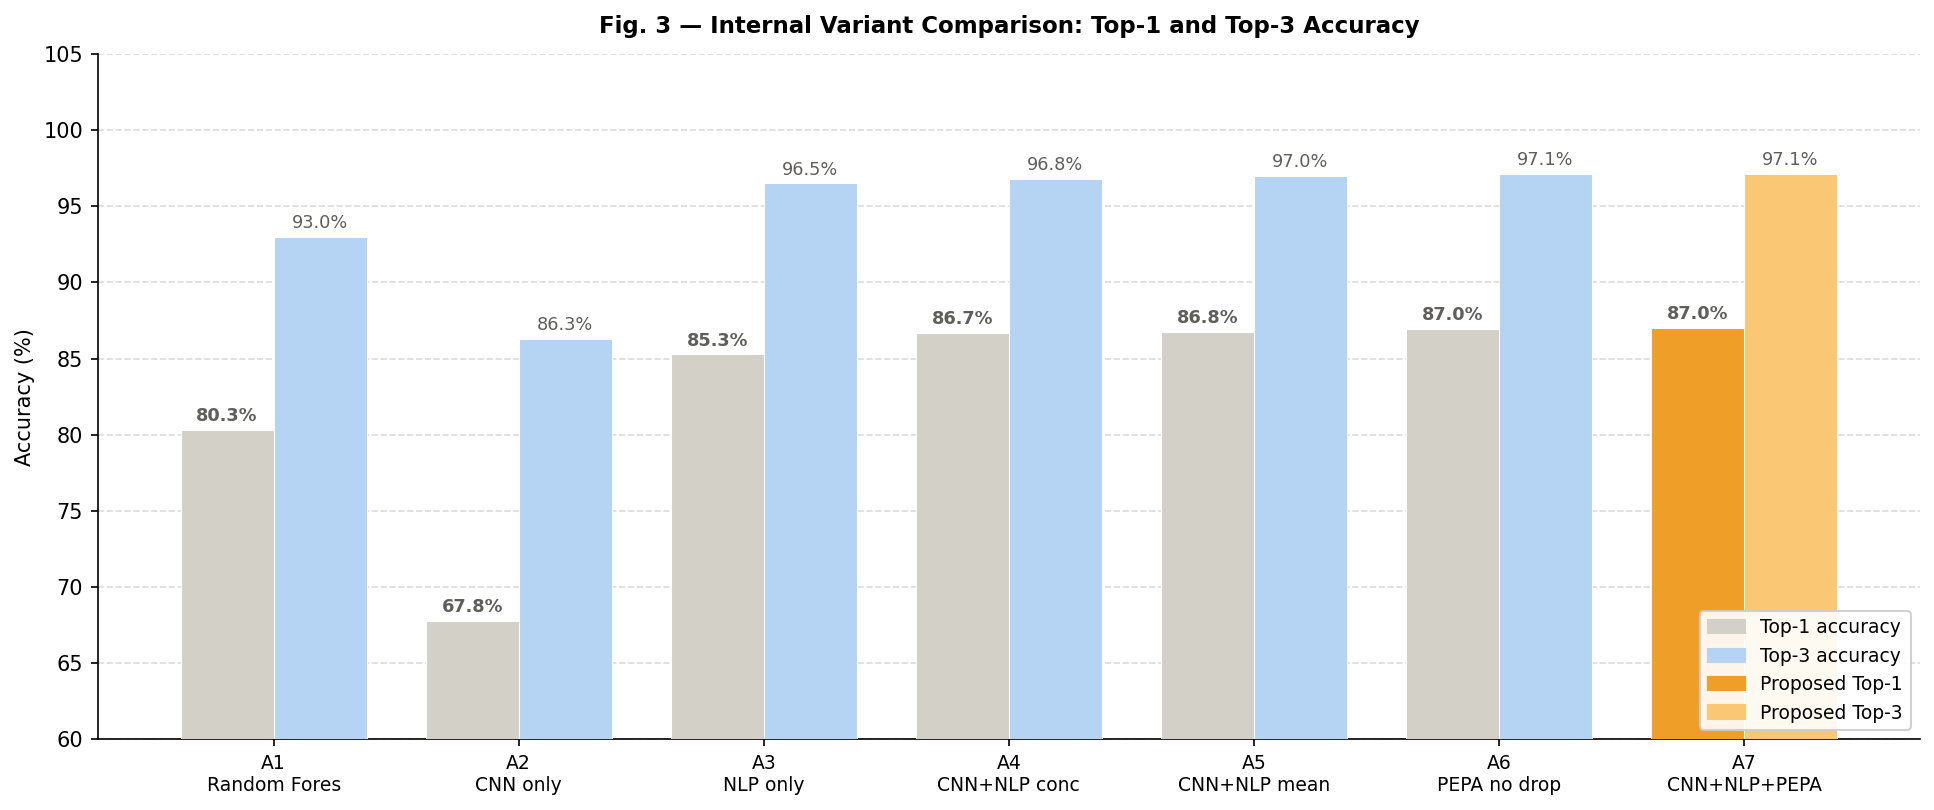

✓ Saved: ../results/figures/fig3_internal_comparison.png


In [10]:
# Cell 3 — Fig 3: Internal Variant Comparison

w       = 0.38
colors1 = [AMBER if v == 'A7' else LGRAY  for v in labels]
colors2 = [AMBER2 if v == 'A7' else LBLUE for v in labels]

fig, ax = plt.subplots(figsize=(13, 5.5))
fig.patch.set_facecolor(WHITE)
ax.set_facecolor(WHITE)

b1 = ax.bar(x - w/2, top1_vals, w, color=colors1, edgecolor='white', linewidth=0.5, zorder=3)
b2 = ax.bar(x + w/2, top3_vals, w, color=colors2, edgecolor='white', linewidth=0.5, zorder=3)

for rect in b1.patches:
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.3,
            f'{rect.get_height():.1f}%',
            ha='center', va='bottom', fontsize=8.5, color=GRAY, fontweight='bold')
for rect in b2.patches:
    ax.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.3,
            f'{rect.get_height():.1f}%',
            ha='center', va='bottom', fontsize=8.5, color=GRAY)

ax.set_xticks(x)
ax.set_xticklabels([f"{r['variant']}\n{r['name'][:12]}" for _, r in df.iterrows()], fontsize=9)
ax.set_ylim(60, 105)
ax.set_ylabel('Accuracy (%)', fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.45, zorder=0)
ax.set_axisbelow(True)

handles = [
    mpatches.Patch(color=LGRAY,  label='Top-1 accuracy'),
    mpatches.Patch(color=LBLUE,  label='Top-3 accuracy'),
    mpatches.Patch(color=AMBER,  label='Proposed Top-1'),
    mpatches.Patch(color=AMBER2, label='Proposed Top-3'),
]
ax.legend(handles=handles, fontsize=9, loc='lower right', framealpha=0.9)
ax.set_title('Fig. 3 — Internal Variant Comparison: Top-1 and Top-3 Accuracy',
             fontsize=11, fontweight='bold', pad=10)

path3 = f'{FIGS}/fig3_internal_comparison.png'
plt.tight_layout()
plt.savefig(path3, dpi=1000, bbox_inches='tight', facecolor=WHITE)
plt.show()
print(f'✓ Saved: {path3}')

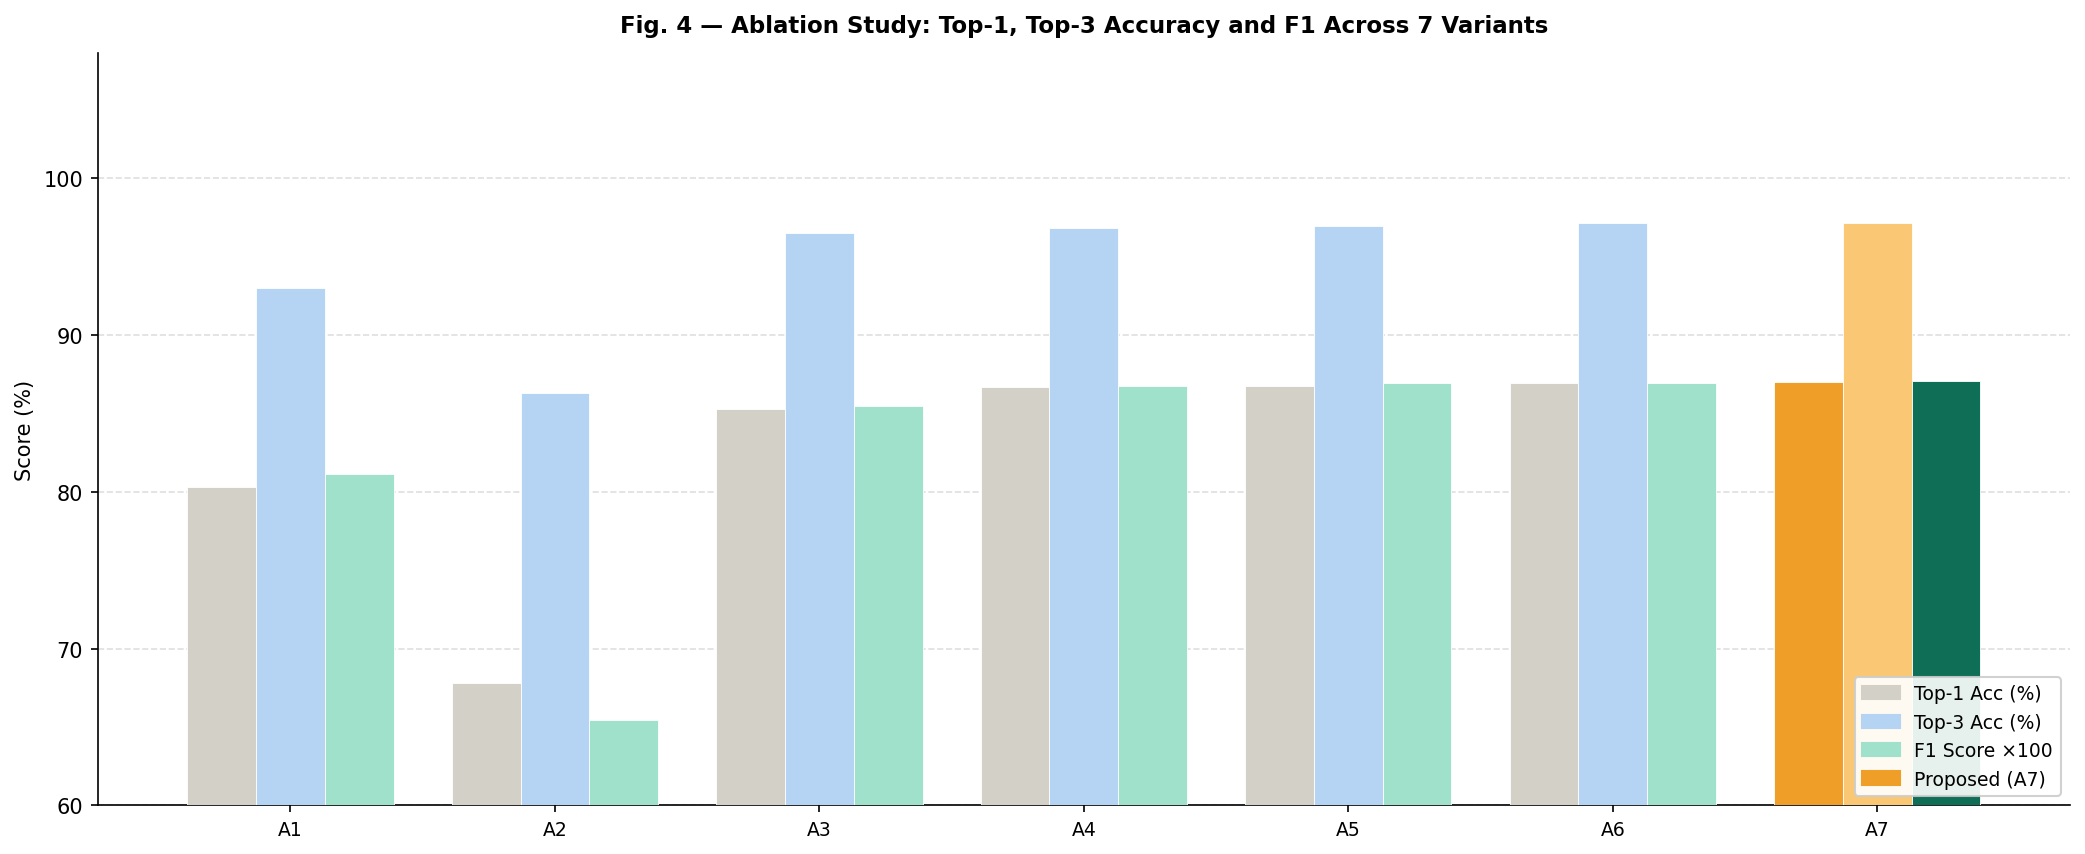

✓ Saved: ../results/figures/fig4_ablation_study.png


In [11]:
# Cell 4 — Fig 4: Ablation Study 3-Metric

f1_scaled = [v * 100 for v in f1_vals]
w         = 0.26
c1 = [AMBER  if v == 'A7' else LGRAY  for v in labels]
c2 = [AMBER2 if v == 'A7' else LBLUE  for v in labels]
c3 = [TEAL   if v == 'A7' else GREEN  for v in labels]

fig, ax = plt.subplots(figsize=(14, 5.8))
fig.patch.set_facecolor(WHITE)
ax.set_facecolor(WHITE)

ax.bar(x - w,   top1_vals, w, color=c1, edgecolor='white', linewidth=0.4, zorder=3)
ax.bar(x,       top3_vals, w, color=c2, edgecolor='white', linewidth=0.4, zorder=3)
ax.bar(x + w,   f1_scaled, w, color=c3, edgecolor='white', linewidth=0.4, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(60, 108)
ax.set_ylabel('Score (%)', fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_axisbelow(True)

handles = [
    mpatches.Patch(color=LGRAY, label='Top-1 Acc (%)'),
    mpatches.Patch(color=LBLUE, label='Top-3 Acc (%)'),
    mpatches.Patch(color=GREEN, label='F1 Score ×100'),
    mpatches.Patch(color=AMBER, label='Proposed (A7)'),
]
ax.legend(handles=handles, fontsize=9, loc='lower right', framealpha=0.9)
ax.set_title('Fig. 4 — Ablation Study: Top-1, Top-3 Accuracy and F1 Across 7 Variants',
             fontsize=11, fontweight='bold', pad=10)

path4 = f'{FIGS}/fig4_ablation_study.png'
plt.tight_layout()
plt.savefig(path4, dpi=1000, bbox_inches='tight', facecolor=WHITE)
plt.show()
print(f'✓ Saved: {path4}')

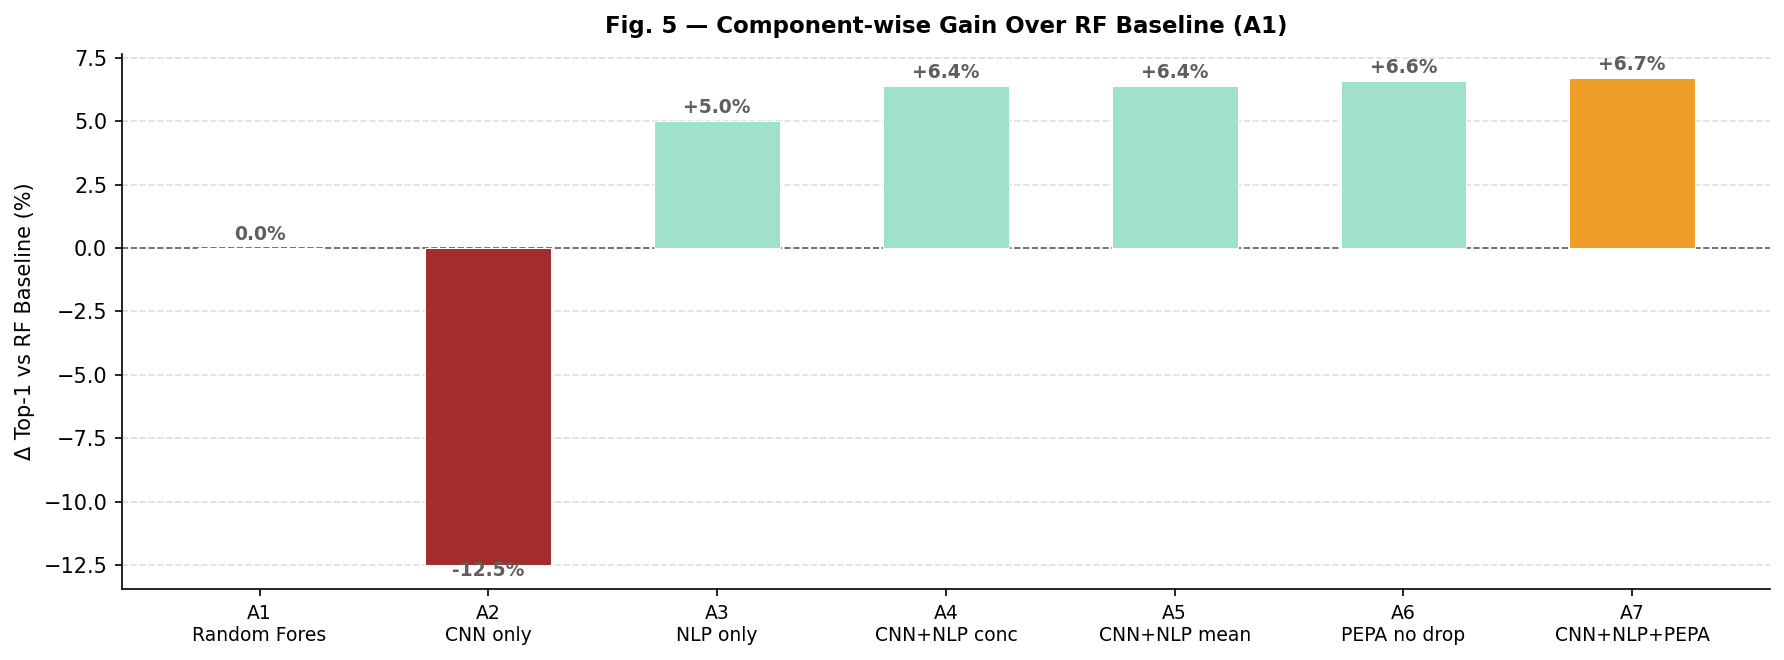

✓ Saved: ../results/figures/fig5_ablation_delta.png


In [12]:
# Cell 5 — Fig 5: Delta Gain Over RF Baseline

baseline = df[df['variant'] == 'A1']['top1'].values[0]
deltas   = [round(v - baseline, 1) for v in top1_vals]
colors   = [AMBER if v == 'A7' else (RED if d < 0 else GREEN)
            for v, d in zip(labels, deltas)]

fig, ax = plt.subplots(figsize=(12, 4.5))
fig.patch.set_facecolor(WHITE)
ax.set_facecolor(WHITE)

bars = ax.bar(x, deltas, 0.55, color=colors, edgecolor='white', linewidth=0.5, zorder=3)
ax.axhline(0, color=GRAY, linewidth=0.8, linestyle='--')

for rect, val in zip(bars.patches, deltas):
    ypos = val + 0.15 if val >= 0 else val - 0.6
    ax.text(rect.get_x() + rect.get_width()/2, ypos,
            f"{'+'if val>0 else''}{val}%",
            ha='center', va='bottom', fontsize=9, fontweight='bold', color=GRAY)

ax.set_xticks(x)
ax.set_xticklabels([f"{r['variant']}\n{r['name'][:12]}" for _, r in df.iterrows()], fontsize=9)
ax.set_ylabel('Δ Top-1 vs RF Baseline (%)', fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_axisbelow(True)
ax.set_title('Fig. 5 — Component-wise Gain Over RF Baseline (A1)',
             fontsize=11, fontweight='bold', pad=10)

path5 = f'{FIGS}/fig5_ablation_delta.png'
plt.tight_layout()
plt.savefig(path5, dpi=1000, bbox_inches='tight', facecolor=WHITE)
plt.show()
print(f'✓ Saved: {path5}')

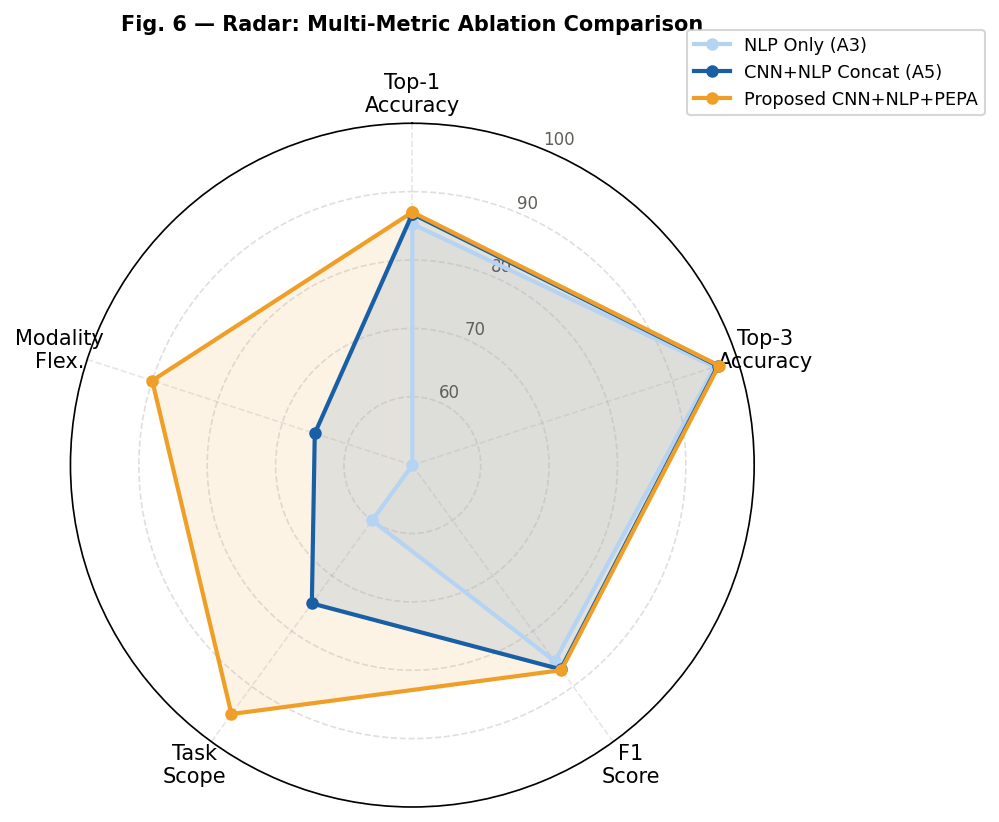

✓ Saved: ../results/figures/fig6_radar.png


In [13]:
# Cell 6 — Fig 6: Radar Chart

categories = ['Top-1\nAccuracy', 'Top-3\nAccuracy', 'F1\nScore', 'Task\nScope', 'Modality\nFlex.']
N      = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]

a3 = df[df['variant'] == 'A3'].iloc[0]
a5 = df[df['variant'] == 'A5'].iloc[0]
a7 = df[df['variant'] == 'A7'].iloc[0]

systems = {
    'NLP Only (A3)':         [a3['top1'], a3['top3'], a3['f1']*100, 60, 50],
    'CNN+NLP Concat (A5)':   [a5['top1'], a5['top3'], a5['f1']*100, 75, 65],
    'Proposed CNN+NLP+PEPA': [a7['top1'], a7['top3'], a7['f1']*100, 95, 90],
}
colors = [LBLUE, BLUE, AMBER]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
fig.patch.set_facecolor(WHITE)
ax.set_facecolor(WHITE)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(50, 100)
ax.set_yticks([60, 70, 80, 90, 100])
ax.set_yticklabels(['60', '70', '80', '90', '100'], fontsize=8, color=GRAY)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.xaxis.grid(True, linestyle='--', alpha=0.3)

for (name, vals), color in zip(systems.items(), colors):
    vals_plot = vals + vals[:1]
    ax.plot(angles, vals_plot, 'o-', linewidth=2, color=color, markersize=5, label=name)
    ax.fill(angles, vals_plot, alpha=0.12, color=color)

ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=8.5)
ax.set_title('Fig. 6 — Radar: Multi-Metric Ablation Comparison',
             fontsize=10, pad=20, fontweight='bold')

path6 = f'{FIGS}/fig6_radar.png'
plt.tight_layout()
plt.savefig(path6, dpi=1000, bbox_inches='tight', facecolor=WHITE)
plt.show()
print(f'✓ Saved: {path6}')

In [14]:
# Cell 7 — Summary
figs = sorted(os.listdir(FIGS))
print('='*55)
print('  ALL FIGURES GENERATED')
print('='*55)
for f in figs:
    size = os.path.getsize(os.path.join(FIGS, f)) // 1024
    print(f'  ✓ {f:<45} {size} KB')
print(f'\n✓ Evaluation complete')
print(f'✓ Figures saved to: {FIGS}')
print(f'✓ Next: cd webapp && python app.py')

  ALL FIGURES GENERATED
  ✓ fig3_internal_comparison.png                  812 KB
  ✓ fig4_ablation_study.png                       576 KB
  ✓ fig5_ablation_delta.png                       545 KB
  ✓ fig6_radar.png                                1250 KB
  ✓ fig7_accuracy_comparison.png                  2333 KB

✓ Evaluation complete
✓ Figures saved to: ../results/figures
✓ Next: cd webapp && python app.py
